In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
titanic = pd.read_csv("D:\\project\\Github_repository\\titanic-survival-classification\\titanic-survival-classification\\src\\titanic.csv")
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [127]:
titanic.shape

(1310, 14)

In [128]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(7), str(7)
memory usage: 210.9 KB


In [129]:
titanic.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [130]:
print(f"unique : {titanic['survived'].unique()}")
print(f"Quantity of null: {titanic['survived'].isna().sum()}")
print(f"index null number: {titanic[titanic['survived'].isna()].index}")
print(f"Quantity of survived: {titanic[titanic['survived'] == 1].value_counts()}")
print(f"Quantity of Drowning: {titanic[titanic['survived'] == 0].value_counts()}")

unique : [ 1.  0. nan]
Quantity of null: 1
index null number: RangeIndex(start=1309, stop=1310, step=1)
Quantity of survived: Series([], Name: count, dtype: int64)
Quantity of Drowning: Series([], Name: count, dtype: int64)


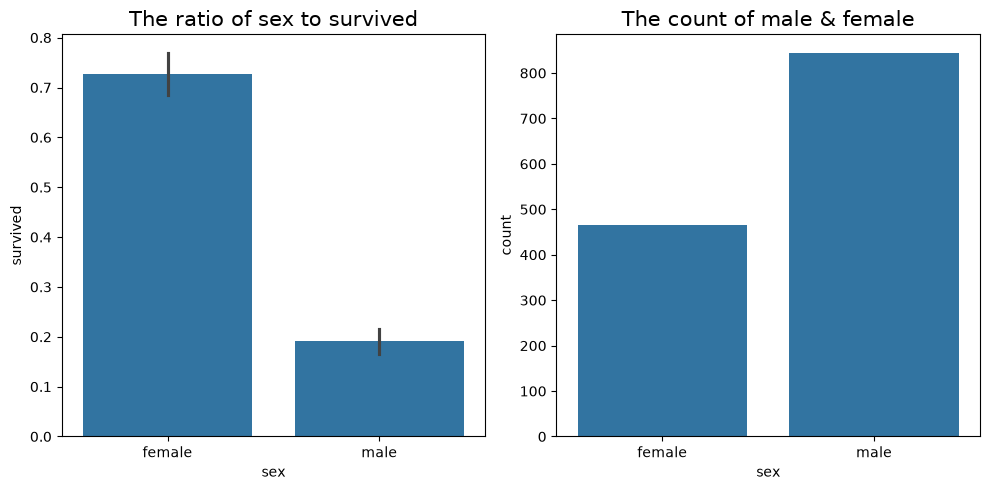

In [131]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='sex', y='survived', ax=axs[0])
axs[0].set_title('The ratio of sex to survived', size=15)

sns.countplot(data=titanic, x='sex', ax=axs[1])
axs[1].set_title('The count of male & female', size=15)

fig.tight_layout()

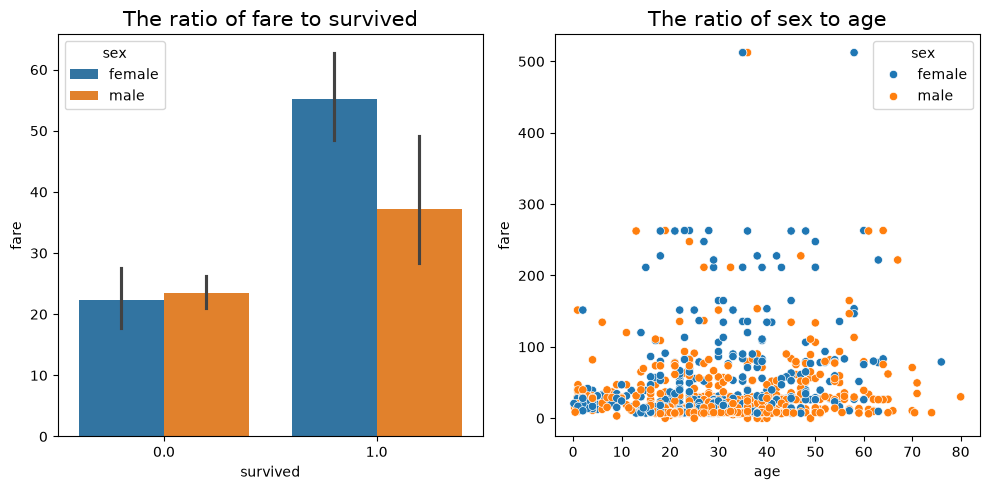

In [132]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='survived', y='fare', hue='sex', ax=axs[0])
axs[0].set_title('The ratio of fare to survived', size=15)

sns.scatterplot(data=titanic, x='age', y='fare', hue='sex', ax=axs[1])
axs[1].set_title('The ratio of sex to age', size=15)

fig.tight_layout()

In [133]:
titanic['ticket'].value_counts()

ticket
CA. 2343        11
1601             8
CA 2144          8
PC 17608         7
S.O.C. 14879     7
                ..
2628             1
2647             1
2656             1
2670             1
315082           1
Name: count, Length: 929, dtype: int64

In [134]:
titanic.iloc[1309]

pclass       NaN
survived     NaN
name         NaN
sex          NaN
age          NaN
sibsp        NaN
parch        NaN
ticket       NaN
fare         NaN
cabin        NaN
embarked     NaN
boat         NaN
body         NaN
home.dest    NaN
Name: 1309, dtype: object

In [135]:
titanic = titanic.drop(titanic.index[1309])

In [136]:
titanic.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

<Axes: >

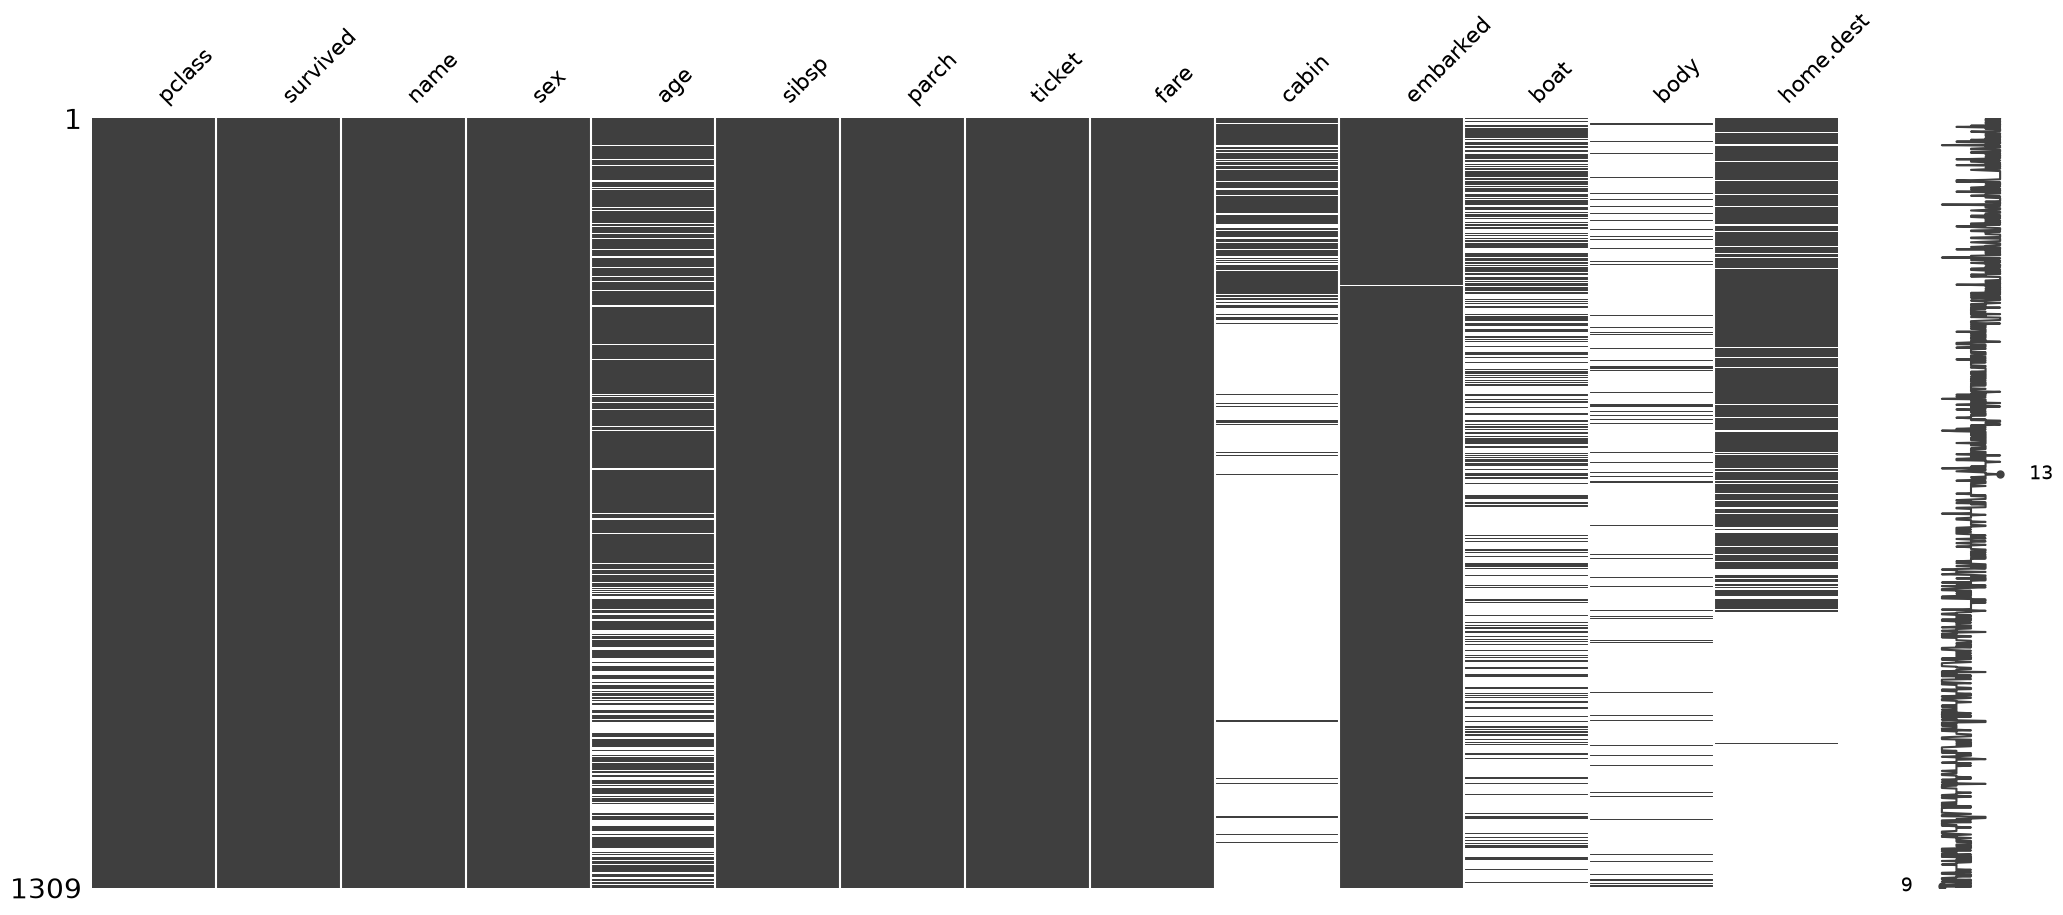

In [137]:
import missingno as msno

msno.matrix(titanic)

In [138]:
titanic['cabin'].value_counts().sum()

np.int64(295)

In [139]:
def drop_missing_columns(df, threshold=50):
    dropped_columns = []

    for col in df.columns:
        if df[col].isnull().mean() * 100 > threshold:
            dropped_columns.append(col)
            df.drop(columns =col, inplace=True)

    return dropped_columns

drop_missing_columns(titanic)

['cabin', 'boat', 'body']

In [140]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,S,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,C,NaN
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,C,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,C,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,C,NaN


In [141]:
titanic.isna().sum()

pclass         0
survived       0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
embarked       2
home.dest    564
dtype: int64

In [142]:
titanic['fare'] = titanic['fare'].fillna(titanic['fare'].median())

In [143]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embarked'].isna().sum()

np.int64(0)

In [144]:
titanic['age']

0       29.0000
1        0.9167
2        2.0000
3       30.0000
4       25.0000
         ...   
1304    14.5000
1305        NaN
1306    26.5000
1307    27.0000
1308    29.0000
Name: age, Length: 1309, dtype: float64

In [145]:
titanic['age'] = titanic['age'].interpolate(method='polynomial', order=2)

In [146]:
titanic['age'] = titanic['age'].round()
titanic['age']

0       29.0
1        1.0
2        2.0
3       30.0
4       25.0
        ... 
1304    14.0
1305    18.0
1306    26.0
1307    27.0
1308    29.0
Name: age, Length: 1309, dtype: float64

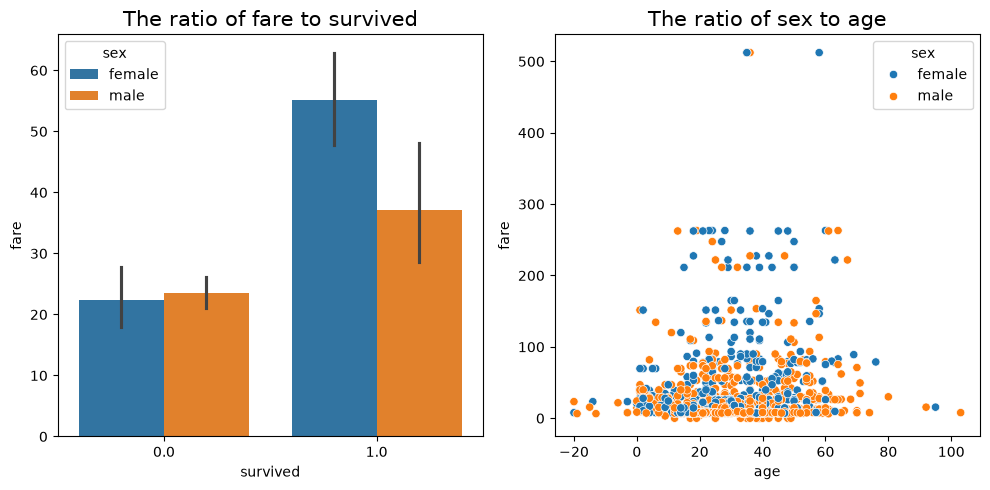

In [147]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='survived', y='fare', hue='sex', ax=axs[0])
axs[0].set_title('The ratio of fare to survived', size=15)

sns.scatterplot(data=titanic, x='age', y='fare', hue='sex', ax=axs[1])
axs[1].set_title('The ratio of sex to age', size=15)

fig.tight_layout()

In [148]:
titanic.isna().sum()

pclass         0
survived       0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
embarked       0
home.dest    564
dtype: int64

In [149]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1309 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   str    
 8   fare       1309 non-null   float64
 9   embarked   1309 non-null   str    
 10  home.dest  745 non-null    str    
dtypes: float64(6), str(5)
memory usage: 177.9 KB


In [150]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"


In [151]:
titanic['alone'] = ((titanic['sibsp'] == 0) & (titanic['parch'] == 0))
titanic['alone']

0        True
1       False
2       False
3       False
4       False
        ...  
1304    False
1305    False
1306     True
1307     True
1308     True
Name: alone, Length: 1309, dtype: bool

In [152]:
titanic['FamilySize'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['FamilySize']

0       1.0
1       4.0
2       4.0
3       4.0
4       4.0
       ... 
1304    2.0
1305    2.0
1306    1.0
1307    1.0
1308    1.0
Name: FamilySize, Length: 1309, dtype: float64

In [153]:
label = ['infant', 'toddler', 'child', 'teen', 'adult', 'middle_age', 'senior', 'old']
bin = [0, 1, 4, 12, 18, 39, 59, 74, np.inf]
titanic['age_group'] = pd.cut(titanic['age'], labels=label, bins=bin)
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,alone,FamilySize,age_group
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO",True,1.0,adult
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,infant
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,toddler
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen
1305,3.0,0.0,"Zabour, Miss. Thamine",female,18.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.0,0.0,0.0,2656,7.2250,C,NaN,True,1.0,adult
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0,0.0,0.0,2670,7.2250,C,NaN,True,1.0,adult


In [154]:
titanic['NamePrefix'] = titanic['name'].str.extract(r',\s*([^.]*)\.')
titanic['name'] = titanic['name'].str.replace(r',.*?\.\s*', '', regex=True)

In [155]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,alone,FamilySize,age_group,NamePrefix
0,1.0,1.0,AllenElisabeth Walton,female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO",True,1.0,adult,Miss
1,1.0,1.0,AllisonHudson Trevor,male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,infant,Master
2,1.0,0.0,AllisonHelen Loraine,female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,toddler,Miss
3,1.0,0.0,AllisonHudson Joshua Creighton,male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mr
4,1.0,0.0,AllisonHudson J C (Bessie Waldo Daniels),female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,ZabourHileni,female,14.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen,Miss
1305,3.0,0.0,ZabourThamine,female,18.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen,Miss
1306,3.0,0.0,ZakarianMapriededer,male,26.0,0.0,0.0,2656,7.2250,C,NaN,True,1.0,adult,Mr
1307,3.0,0.0,ZakarianOrtin,male,27.0,0.0,0.0,2670,7.2250,C,NaN,True,1.0,adult,Mr


In [156]:
titanic['who'] = np.select(
    [
        titanic['age'] < 16,
        titanic['sex'] == 'female'
    ],
    [
        'child',
        'woman'
    ],
    default='man'
)
titanic['who']

0       woman
1       child
2       child
3         man
4       woman
        ...  
1304    child
1305    woman
1306      man
1307      man
1308      man
Name: who, Length: 1309, dtype: str

In [157]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,alone,FamilySize,age_group,NamePrefix,who
0,1.0,1.0,AllenElisabeth Walton,female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO",True,1.0,adult,Miss,woman
1,1.0,1.0,AllisonHudson Trevor,male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,infant,Master,child
2,1.0,0.0,AllisonHelen Loraine,female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,toddler,Miss,child
3,1.0,0.0,AllisonHudson Joshua Creighton,male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mr,man
4,1.0,0.0,AllisonHudson J C (Bessie Waldo Daniels),female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mrs,woman


In [158]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   pclass      1309 non-null   float64 
 1   survived    1309 non-null   float64 
 2   name        1309 non-null   str     
 3   sex         1309 non-null   str     
 4   age         1309 non-null   float64 
 5   sibsp       1309 non-null   float64 
 6   parch       1309 non-null   float64 
 7   ticket      1309 non-null   str     
 8   fare        1309 non-null   float64 
 9   embarked    1309 non-null   str     
 10  home.dest   745 non-null    str     
 11  alone       1309 non-null   bool    
 12  FamilySize  1309 non-null   float64 
 13  age_group   1295 non-null   category
 14  NamePrefix  1309 non-null   str     
 15  who         1309 non-null   str     
dtypes: bool(1), category(1), float64(7), str(7)
memory usage: 211.3 KB


In [159]:
titanic['sex'] = titanic['sex'].astype('category')
titanic['embarked'] = titanic['embarked'].astype('category')

In [160]:
titanic = pd.get_dummies(titanic, columns=['embarked'], dtype=int)
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,home.dest,alone,FamilySize,age_group,NamePrefix,who,embarked_C,embarked_Q,embarked_S
0,1.0,1.0,AllenElisabeth Walton,female,29.0,0.0,0.0,24160,211.3375,"St Louis, MO",True,1.0,adult,Miss,woman,0,0,1
1,1.0,1.0,AllisonHudson Trevor,male,1.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,infant,Master,child,0,0,1
2,1.0,0.0,AllisonHelen Loraine,female,2.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,toddler,Miss,child,0,0,1
3,1.0,0.0,AllisonHudson Joshua Creighton,male,30.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mr,man,0,0,1
4,1.0,0.0,AllisonHudson J C (Bessie Waldo Daniels),female,25.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mrs,woman,0,0,1


In [161]:
titanic = titanic.drop(columns=['name', 'home.dest', 'ticket'])

In [162]:
titanic['alone'] = titanic['alone'].astype(int)

In [163]:
titanic['sex_code'] = titanic['sex'].cat.codes

In [164]:
titanic['age_group'] = pd.Categorical(
    titanic['age_group'],
    categories=['infant', 'toddler', 'child', 'teen', 'adult', 'middle_age', 'senior', 'old'],
    ordered=True
)

titanic['age_group_code'] = titanic['age_group'].cat.codes

In [165]:
titanic = pd.get_dummies(
    titanic,
    columns=['who'],
    dtype=int
)

In [166]:
titanic['NamePrefix'].value_counts()

NamePrefix
Mr              757
Miss            260
Mrs             197
Master           61
Dr                8
Rev               8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Capt              1
Lady              1
Sir               1
Dona              1
Jonkheer          1
the Countess      1
Don               1
Name: count, dtype: int64

In [167]:
rare_titles = [
    'Dona', 'Lady', 'Mme', 'the Countess',
    'Jonkheer', 'Mlle', 'Don', 'Capt',
    'Sir', 'Ms', 'Major', 'Col', 'Dr', 'Rev'
]

titanic['NamePrefix'] = titanic['NamePrefix'].replace(
    rare_titles,
    'Rare'
)

In [168]:
titanic = pd.get_dummies(
    titanic,
    columns=['NamePrefix'],
    dtype=int
)

In [169]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   pclass             1309 non-null   float64 
 1   survived           1309 non-null   float64 
 2   sex                1309 non-null   category
 3   age                1309 non-null   float64 
 4   sibsp              1309 non-null   float64 
 5   parch              1309 non-null   float64 
 6   fare               1309 non-null   float64 
 7   alone              1309 non-null   int64   
 8   FamilySize         1309 non-null   float64 
 9   age_group          1295 non-null   category
 10  embarked_C         1309 non-null   int64   
 11  embarked_Q         1309 non-null   int64   
 12  embarked_S         1309 non-null   int64   
 13  sex_code           1309 non-null   int8    
 14  age_group_code     1309 non-null   int8    
 15  who_child          1309 non-null   int64   
 16  who_man          

In [170]:
titanic.head()

,pclass,survived,sex,age,sibsp,parch,fare,alone,FamilySize,age_group,...,sex_code,age_group_code,who_child,who_man,who_woman,NamePrefix_Master,NamePrefix_Miss,NamePrefix_Mr,NamePrefix_Mrs,NamePrefix_Rare
0,1.0,1.0,female,29.0,0.0,0.0,211.3375,1,1.0,adult,...,0,4,0,0,1,0,1,0,0,0
1,1.0,1.0,male,1.0,1.0,2.0,151.5500,0,4.0,infant,...,1,0,1,0,0,1,0,0,0,0
2,1.0,0.0,female,2.0,1.0,2.0,151.5500,0,4.0,toddler,...,0,1,1,0,0,0,1,0,0,0
3,1.0,0.0,male,30.0,1.0,2.0,151.5500,0,4.0,adult,...,1,4,0,1,0,0,0,1,0,0
4,1.0,0.0,female,25.0,1.0,2.0,151.5500,0,4.0,adult,...,0,4,0,0,1,0,0,0,1,0


In [171]:
abs(titanic.corr(numeric_only=True)['survived']).sort_values(ascending=False)

survived             1.000000
NamePrefix_Mr        0.529016
sex_code             0.528693
who_man              0.516781
who_woman            0.485052
NamePrefix_Mrs       0.350699
pclass               0.312469
NamePrefix_Miss      0.302225
fare                 0.244414
alone                0.201719
embarked_C           0.182123
embarked_S           0.150542
who_child            0.100251
age_group_code       0.095977
parch                0.082660
age                  0.058444
NamePrefix_Master    0.057436
sibsp                0.027825
FamilySize           0.026876
NamePrefix_Rare      0.019899
embarked_Q           0.016071
Name: survived, dtype: float64

In [172]:
X = titanic.select_dtypes(include=['float', 'int'])
X = X.drop(columns='survived')
y = titanic['survived']

In [173]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100)

forest.fit(X, y)
forest_important = forest.feature_importances_

In [174]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, max_leaf_nodes=50)

tree.fit(X, y)
tree_important = tree.feature_importances_

In [175]:
pd.concat([
    pd.Series(forest_important, name='forest_important'),
    pd.Series(tree_important, name='tree_important'),
    pd.Series(X.columns, name='columns')
], axis=1).sort_values(['tree_important', 'forest_important'], ascending=False)

,forest_important,tree_important,columns
15,0.101227,0.624946,NamePrefix_Mr
0,0.082365,0.203047,pclass
6,0.040568,0.076937,FamilySize
11,0.073047,0.071086,who_man
1,0.239728,0.023984,age
4,0.233279,0.000000,fare
12,0.078121,0.000000,who_woman
2,0.030144,0.000000,sibsp
16,0.025455,0.000000,NamePrefix_Mrs
3,0.019597,0.000000,parch


In [176]:
X_new = X.drop(columns=['NamePrefix_Rare', 'embarked_Q', 'NamePrefix_Master', 'who_child', 'alone', 'parch'])

In [1]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [2]:
# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [3]:
# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [207]:
X_tarin, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [208]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

standard_scale = StandardScaler()
minmax_scale = MinMaxScaler()

In [209]:
X_train_scaled = standard_scale.fit_transform(X_tarin)
X_test_scaled = standard_scale.transform(X_test)

In [215]:
from utils import evaluate, plot_confusion_matrix, evaluate_models

# Logistic Regression

In [213]:
logistic = LogisticRegression(max_iter=1000)

logistic.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [217]:
y_pred_log = logistic.predict(X_test_scaled)

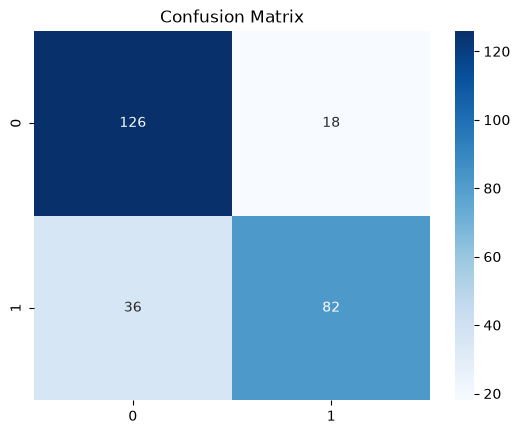

In [218]:
plot_confusion_matrix(logistic, X_test_scaled, y_test)

In [219]:
evaluate(logistic, X_test_scaled, y_test)

{'Accuracy': 0.7938931297709924,
 'Precision': 0.82,
 'Recall': 0.6949152542372882,
 'F1 Score': 0.7522935779816514,
 'ROC-AUC': 0.8617290489642184}

# KNeighbors Classifier

In [226]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [227]:
y_pred_knn = knn.predict(X_test_scaled)

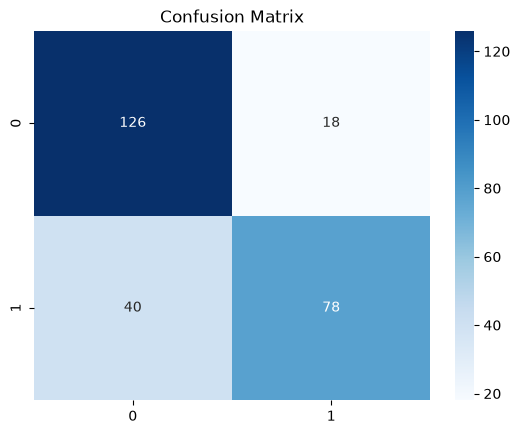

In [228]:
plot_confusion_matrix(knn, X_test_scaled, y_test)

In [229]:
evaluate(knn, X_test_scaled, y_test)

{'Accuracy': 0.7786259541984732,
 'Precision': 0.8125,
 'Recall': 0.6610169491525424,
 'F1 Score': 0.7289719626168224,
 'ROC-AUC': 0.8252118644067796}